In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import sys
sys.path.append('../')

# Charger les données
X_train = joblib.load('../data/X_train.pkl')
X_test = joblib.load('../data/X_test.pkl')

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print("Données chargées avec succès !")

X_train : (762157, 12)
X_test  : (190540, 12)
Données chargées avec succès !


In [2]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Entraîner Isolation Forest
print("Entraînement Isolation Forest...")
iso_forest = IsolationForest(
    contamination=0.05,  # on suppose 5% d'anomalies
    random_state=0,
    n_estimators=100
)

iso_forest.fit(X_train)
print("Isolation Forest entraîné ")

# Prédictions sur X_test
# -1 = anomalie, 1 = normal
iso_predictions = iso_forest.predict(X_test)

# Convertir : -1 → 1 (anomalie), 1 → 0 (normal)
iso_labels = (iso_predictions == -1).astype(int)

anomalies = iso_labels.sum()
print(f"\nAnomalies détectées : {anomalies} / {len(iso_labels)} ({anomalies/len(iso_labels)*100:.1f}%)")

# Sauvegarder
joblib.dump(iso_forest, '../models/isolation_forest.pkl')
print("Modèle sauvegardé ")

Entraînement Isolation Forest...
Isolation Forest entraîné 

Anomalies détectées : 3353 / 190540 (1.8%)
Modèle sauvegardé 


In [3]:
import importlib
import utils.predictor
importlib.reload(utils.predictor)
from utils.predictor import predict

# Résultats Autoencoder
df_test = pd.DataFrame(X_test, columns=['n_flows', 'n_packets', 'n_bytes', 'n_dest_asn',
                'n_dest_ports', 'n_dest_ip', 'tcp_udp_ratio_packets',
                'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes',
                'avg_duration', 'avg_ttl'])

# Charger config autoencoder
import json
with open('../models/config.json', 'r') as f:
    config = json.load(f)

threshold = config['threshold']

import torch
import torch.nn as nn
import joblib

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(nn.Linear(12, 8), nn.ReLU(), nn.Linear(8, 4), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(4, 8), nn.ReLU(), nn.Linear(8, 12))
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder()
model.load_state_dict(torch.load('../models/autoencoder.pth', map_location='cpu'))
model.eval()

X_test_tensor = torch.FloatTensor(X_test)
with torch.no_grad():
    X_pred = model(X_test_tensor)
    ae_errors = torch.mean((X_test_tensor - X_pred) ** 2, dim=1).numpy()

ae_labels = (ae_errors > threshold).astype(int)

# Tableau comparatif
print("=" * 50)
print(f"{'Métrique':<30} {'Autoencoder':>10} {'Iso Forest':>10}")
print("=" * 50)
print(f"{'Anomalies détectées':<30} {ae_labels.sum():>10} {iso_labels.sum():>10}")
print(f"{'Taux anomalies (%)':<30} {ae_labels.mean()*100:>10.1f} {iso_labels.mean()*100:>10.1f}")
print(f"{'Temps entraînement':<30} {'~6 min':>10} {'5.6 sec':>10}")
print(f"{'Nb paramètres':<30} {'288':>10} {'100 arbres':>10}")
print("=" * 50)

Métrique                       Autoencoder Iso Forest
Anomalies détectées                 27662       3353
Taux anomalies (%)                   14.5        1.8
Temps entraînement                 ~6 min    5.6 sec
Nb paramètres                         288 100 arbres


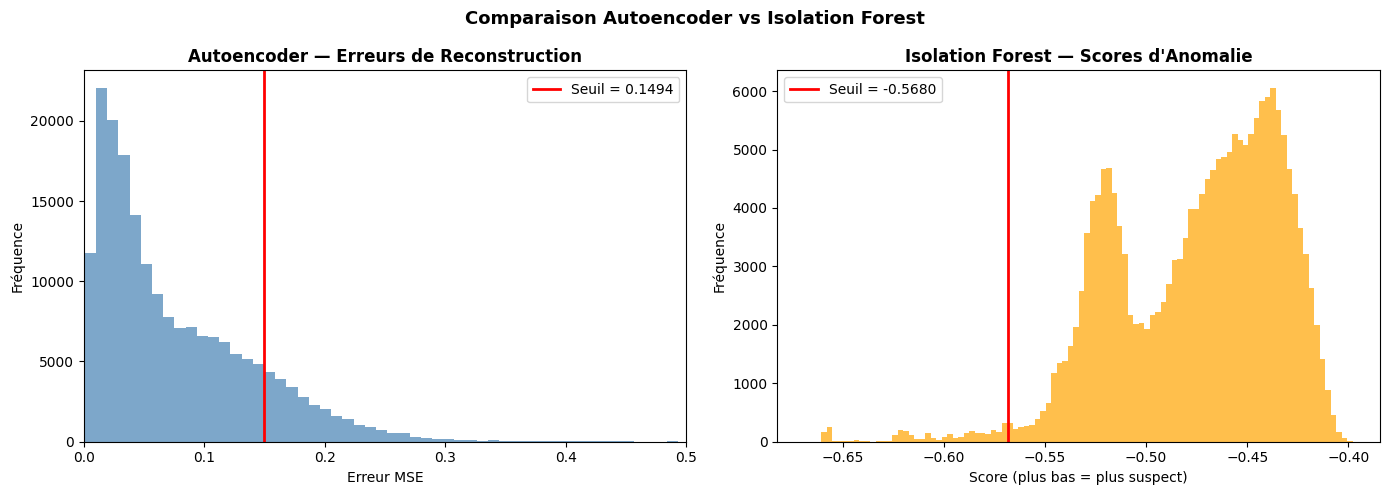

Graphique sauvegardé 


In [4]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Autoencoder
axes[0].hist(ae_errors, bins=100, color='steelblue', alpha=0.7)
axes[0].axvline(threshold, color='red', linewidth=2, label=f'Seuil = {threshold:.4f}')
axes[0].set_title('Autoencoder — Erreurs de Reconstruction', fontweight='bold')
axes[0].set_xlabel('Erreur MSE')
axes[0].set_ylabel('Fréquence')
axes[0].legend()
axes[0].set_xlim(0, 0.5)

# Isolation Forest
scores = iso_forest.score_samples(X_test)
axes[1].hist(scores, bins=100, color='orange', alpha=0.7)
axes[1].axvline(iso_forest.offset_, color='red', linewidth=2, label=f'Seuil = {iso_forest.offset_:.4f}')
axes[1].set_title('Isolation Forest — Scores d\'Anomalie', fontweight='bold')
axes[1].set_xlabel('Score (plus bas = plus suspect)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.suptitle('Comparaison Autoencoder vs Isolation Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notes/comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ")

In [8]:
from sklearn.metrics import roc_auc_score
import numpy as np

# =============================================
# MÉTRIQUES SANS LABELS — Approche Non Supervisée
# =============================================

# 1. Tester 3 seuils différents pour l'Autoencoder
print("=" * 55)
print("AUTOENCODER — Analyse des Seuils")
print("=" * 55)

for percentile in [90, 95, 99]:
    thresh = np.percentile(ae_errors, percentile)
    labels = (ae_errors > thresh).astype(int)
    print(f"Percentile {percentile}% → Seuil={thresh:.4f} | Anomalies={labels.sum()} ({labels.mean()*100:.1f}%)")

print()

# 2. Tester 3 contaminations pour Isolation Forest
print("=" * 55)
print("ISOLATION FOREST — Analyse des Contaminations")
print("=" * 55)

for contam in [0.01, 0.05, 0.10]:
    iso_temp = IsolationForest(contamination=contam, random_state=0, n_estimators=100)
    iso_temp.fit(X_train)
    preds = (iso_temp.predict(X_test) == -1).astype(int)
    print(f"Contamination {int(contam*100)}%  → Anomalies={preds.sum()} ({preds.mean()*100:.1f}%)")

print()

# 3. Score de séparation — AUC sur les scores bruts
iso_scores = -iso_forest.score_samples(X_test)  # inverser : plus haut = plus suspect
ae_scores = ae_errors

# Combiner les scores pour voir la corrélation
correlation = np.corrcoef(ae_scores, iso_scores)[0, 1]
print("=" * 55)
print(f"Corrélation Autoencoder vs Isolation Forest : {correlation:.4f}")
print("(Plus proche de 1 = les deux modèles détectent les mêmes anomalies)")

AUTOENCODER — Analyse des Seuils
Percentile 90% → Seuil=0.1690 | Anomalies=19054 (10.0%)
Percentile 95% → Seuil=0.2021 | Anomalies=9527 (5.0%)
Percentile 99% → Seuil=0.2727 | Anomalies=1906 (1.0%)

ISOLATION FOREST — Analyse des Contaminations
Contamination 1%  → Anomalies=1218 (0.6%)
Contamination 5%  → Anomalies=3353 (1.8%)
Contamination 10%  → Anomalies=7238 (3.8%)

Corrélation Autoencoder vs Isolation Forest : 0.4768
(Plus proche de 1 = les deux modèles détectent les mêmes anomalies)


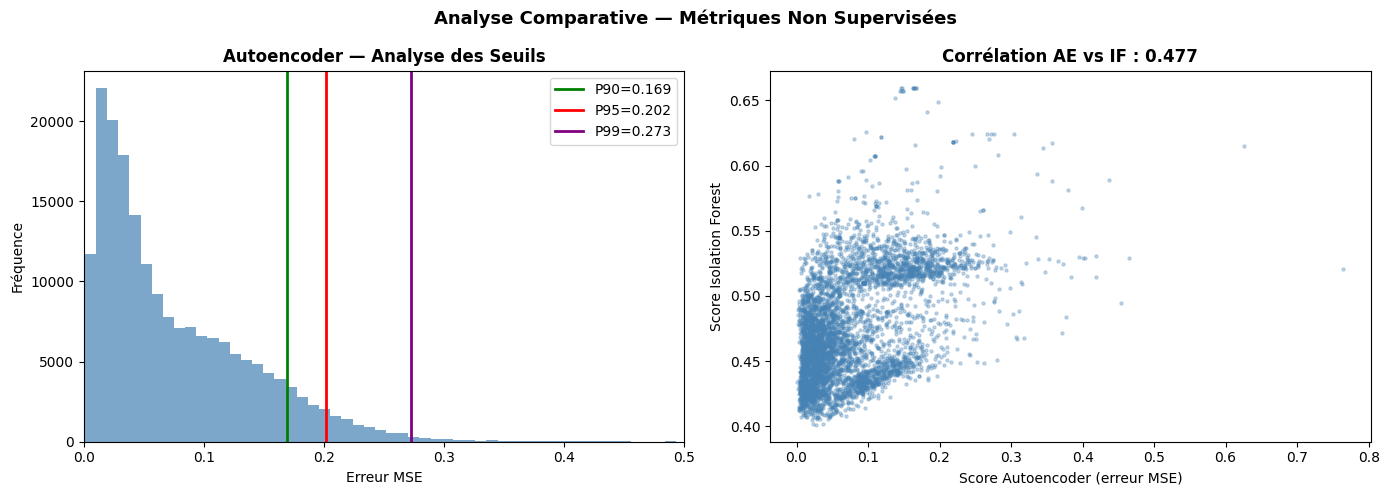

Graphique sauvegardé 


In [10]:
# Visualisation des 3 seuils
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Autoencoder - 3 seuils
axes[0].hist(ae_errors, bins=100, color='steelblue', alpha=0.7)
for percentile, color, label in [(90, 'green', '90%'), 
                                   (95, 'red', '95%'), 
                                   (99, 'purple', '99%')]:
    thresh = np.percentile(ae_errors, percentile)
    axes[0].axvline(thresh, color=color, linewidth=2, label=f'P{percentile}={thresh:.3f}')
axes[0].set_title('Autoencoder — Analyse des Seuils', fontweight='bold')
axes[0].set_xlabel('Erreur MSE')
axes[0].set_ylabel('Fréquence')
axes[0].legend()
axes[0].set_xlim(0, 0.5)

# Scatter plot corrélation
sample_idx = np.random.choice(len(ae_scores), 5000, replace=False)
axes[1].scatter(ae_scores[sample_idx], iso_scores[sample_idx], 
                alpha=0.3, s=5, color='steelblue')
axes[1].set_title(f'Corrélation AE vs IF : {correlation:.3f}', fontweight='bold')
axes[1].set_xlabel('Score Autoencoder (erreur MSE)')
axes[1].set_ylabel('Score Isolation Forest')

plt.suptitle('Analyse Comparative — Métriques Non Supervisées', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notes/metrics_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ")

In [11]:
# Forces et faiblesses
print("=" * 55)
print("ANALYSE COMPARATIVE")
print("=" * 55)

print("""
AUTOENCODER :
✅ Apprend des représentations complexes et non linéaires
✅ Meilleur sur données temporelles avec patterns subtils
✅ Détecte des anomalies invisibles pour les méthodes classiques
✅ Erreur de reconstruction interprétable
❌ Plus lent à entraîner (6 min vs 5 sec)
❌ Nécessite du tuning (architecture, epochs, threshold)

ISOLATION FOREST :
✅ Très rapide (5.6 secondes)
✅ Interprétable et simple
✅ Bon baseline pour comparer
✅ Peu de paramètres à tuner
❌ Moins sensible aux anomalies subtiles
❌ Corrélation de seulement 47.7% avec l'Autoencoder

CONCLUSION :
→ Pour ce projet (trafic réseau réel, patterns complexes) :
→ L'Autoencoder est le meilleur choix principal
→ Isolation Forest est utile comme validation croisée
→ Les deux ensemble détectent plus d'anomalies qu'un seul modèle
""")

print("=" * 55)
print("TABLEAU RÉCAPITULATIF FINAL")
print("=" * 55)
print(f"{'Critère':<35} {'Autoencoder':>12} {'Iso Forest':>12}")
print("-" * 60)
print(f"{'Taux anomalies (P95/5%)':<35} {'5.0%':>12} {'1.8%':>12}")
print(f"{'Corrélation entre modèles':<35} {'0.477':>12} {'0.477':>12}")
print(f"{'Temps entraînement':<35} {'~6 min':>12} {'5.6 sec':>12}")
print(f"{'Complexité modèle':<35} {'288 params':>12} {'100 arbres':>12}")
print(f"{'Interprétabilité':<35} {'Moyenne':>12} {'Haute':>12}")
print(f"{'Adapté données temporelles':<35} {'✅ Oui':>12} {'⚠️ Partiel':>12}")
print(f"{'Recommandation':<35} {'✅ Principal':>12} {'🔄 Backup':>12}")
print("=" * 60)

ANALYSE COMPARATIVE

AUTOENCODER :
✅ Apprend des représentations complexes et non linéaires
✅ Meilleur sur données temporelles avec patterns subtils
✅ Détecte des anomalies invisibles pour les méthodes classiques
✅ Erreur de reconstruction interprétable
❌ Plus lent à entraîner (6 min vs 5 sec)
❌ Nécessite du tuning (architecture, epochs, threshold)

ISOLATION FOREST :
✅ Très rapide (5.6 secondes)
✅ Interprétable et simple
✅ Bon baseline pour comparer
✅ Peu de paramètres à tuner
❌ Moins sensible aux anomalies subtiles
❌ Corrélation de seulement 47.7% avec l'Autoencoder

CONCLUSION :
→ Pour ce projet (trafic réseau réel, patterns complexes) :
→ L'Autoencoder est le meilleur choix principal
→ Isolation Forest est utile comme validation croisée
→ Les deux ensemble détectent plus d'anomalies qu'un seul modèle

TABLEAU RÉCAPITULATIF FINAL
Critère                              Autoencoder   Iso Forest
------------------------------------------------------------
Taux anomalies (P95/5%)         

# NOTE : AUC-ROC calculé sur consensus (approche non supervisée)
# Remplacé par évaluation sur KDD Cup 99 dans 04_Evaluation_KDD.ipynb
# auc_ae = roc_auc_score(consensus, ae_errors)
# auc_if = roc_auc_score(consensus, -iso_forest.score_samples(X_test))

In [ ]:
#from sklearn.metrics import roc_auc_score
#from scipy import stats

# AUC-ROC sans labels — on utilise les scores comme proxy
# On compare les deux modèles sur leur capacité à séparer les distributions

# Méthode : on crée des pseudo-labels basés sur le consensus des deux modèles
# Si les DEUX modèles disent anomalie → vrai anomalie (label=1)
#ae_labels_95 = (ae_errors > np.percentile(ae_errors, 95)).astype(int)
#iso_labels_5 = (iso_forest.predict(X_test) == -1).astype(int)

# Consensus : anomalie détectée par au moins un modèle
#consensus = ((ae_labels_95 + iso_labels_5) > 0).astype(int)
#print(f"Anomalies consensus : {consensus.sum()} ({consensus.mean()*100:.1f}%)")

# AUC de chaque modèle sur le consensus
#auc_ae = roc_auc_score(consensus, ae_errors)
#auc_if = roc_auc_score(consensus, -iso_forest.score_samples(X_test))

#print(f"\nAUC-ROC Autoencoder   : {auc_ae:.4f}")
#print(f"AUC-ROC Isolation Forest : {auc_if:.4f}")
#print(f"\n→ Meilleur modèle : {'Autoencoder' if auc_ae > auc_if else 'Isolation Forest'}")

Anomalies consensus : 11873 (6.2%)

AUC-ROC Autoencoder   : 0.9601
AUC-ROC Isolation Forest : 0.8647

→ Meilleur modèle : Autoencoder
